In [1]:
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. 피클에서 전처리된 데이터 불러오기
with open("X_train.pkl", "rb") as f:
    X_train = pickle.load(f)
with open("X_test.pkl", "rb") as f:
    X_test = pickle.load(f)
with open("y_train.pkl", "rb") as f:
    y_train = pickle.load(f)
with open("y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

# 2. 스케일링 (다시 진행)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. 모델 훈련
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 4. 예측
y_pred = model.predict(X_test_scaled)

# 5. 성능 평가 출력 (추가)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


RMSE: 4.93
R² Score: 0.67


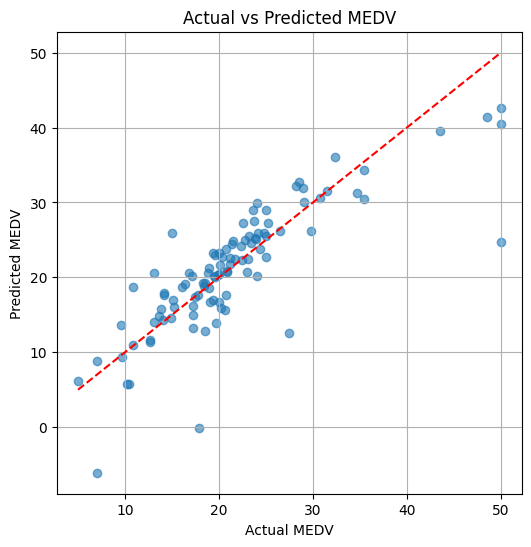

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted MEDV")
plt.grid(True)
plt.show()

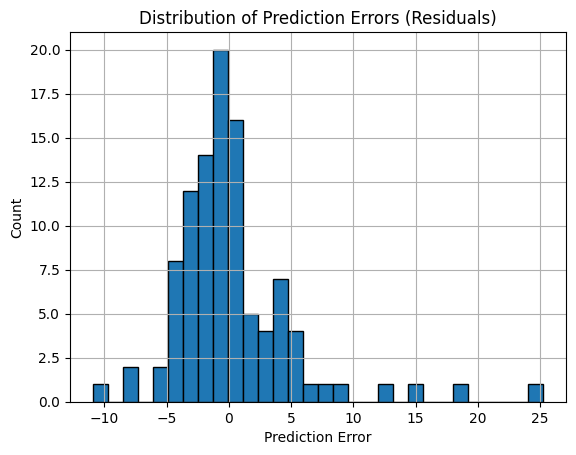

In [3]:
import numpy as np

residuals = y_test - y_pred
plt.hist(residuals, bins=30, edgecolor='k')
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.grid(True)
plt.show()


    Feature  Coefficient
12    LSTAT    -3.611658
5        RM     3.145240
7       DIS    -3.081908
8       RAD     2.251407
10  PTRATIO    -2.037752
4       NOX    -2.022319
9       TAX    -1.767014
11        B     1.129568
0      CRIM    -1.002135
3      CHAS     0.718738
1        ZN     0.696269
2     INDUS     0.278065
6       AGE    -0.176048


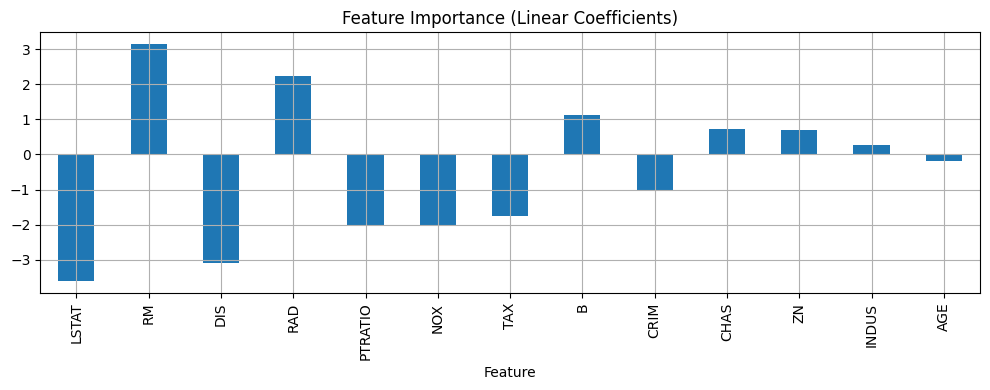

In [7]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df)

# 시각화
import matplotlib.pyplot as plt
coef_df.plot(kind="bar", x="Feature", y="Coefficient", legend=False, figsize=(10, 4), title="Feature Importance (Linear Coefficients)")
plt.tight_layout()
plt.grid(True)
plt.show()


In [8]:
import joblib

joblib.dump(model, "linear_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [9]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results.to_csv("predictions.csv", index=False)


In [10]:
import pickle

with open("linear_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [11]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 성능 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 4.93
R² Score: 0.67
